In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from scipy.spatial import cKDTree
import cv2
import os

In [2]:
GT_DIR = os.path.join("images", "ground_truth")
ALGO_DIR = os.path.join("images", "algorithms")
BINARIZATION_THRESHOLD = 127
IMAGE_GRAY_SCALE = 255

In [3]:
def load_images_from_folder(folder_path):
    images = []
    filenames = []
    for filename in sorted(os.listdir(folder_path)):
        img_path = os.path.join(folder_path, filename)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is not None:
            images.append(img)
            filenames.append(filename)
    return images, filenames

# Data Visualization

In [4]:
def plot_gt_images(gt_images, filenames, title="Ground Truth (GT) Images"):
    num_images = len(gt_images)
    fig, axes = plt.subplots(1, num_images, figsize=(4 * num_images, 4))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    if num_images == 1:
        axes = [axes]
        
    for i in range(num_images):
        axes[i].imshow(gt_images[i], cmap='gray')
        axes[i].set_title(f"Image: {filenames[i]}", fontsize=12)
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

In [5]:
def plot_algorithms_grid(algos_data, algorithms, filenames, title="Algorithms Predictions (6x4)"):
    num_algos = len(algorithms)
    num_images = len(filenames)
    
    fig, axes = plt.subplots(num_algos, num_images, figsize=(4 * num_images, 3 * num_algos))
    fig.suptitle(title, fontsize=20, fontweight='bold', y=1)
    
    if num_algos == 1 and num_images == 1:
        axes = np.array([[axes]])
    elif num_algos == 1:
        axes = axes[np.newaxis, :]
    elif num_images == 1:
        axes = axes[:, np.newaxis]

    for i, algo_name in enumerate(algorithms):
        for j in range(num_images):
            img = algos_data[algo_name][j]
            ax = axes[i, j]
            
            ax.imshow(img, cmap='gray')
            
            if i == 0:
                ax.set_title(filenames[j], fontsize=12, fontweight='bold')
            
            if j == 0:
                ax.set_ylabel(algo_name, fontsize=14, fontweight='bold')
                
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()

In [6]:
def plot_images(gt_path, algo_base_path):
    gt_images, gt_filenames = load_images_from_folder(gt_path)
    algorithms = sorted([d for d in os.listdir(algo_base_path) if os.path.isdir(os.path.join(algo_base_path, d))])
    algos_data = {algo: load_images_from_folder(os.path.join(algo_base_path, algo))[0] for algo in algorithms}

    print(">>> Plotting Ground Truth Images... <<<")
    plot_gt_images(gt_images, gt_filenames)
    
    print(">>> Plotting Algorithms Predictions Grid... <<<")
    plot_algorithms_grid(algos_data, algorithms, gt_filenames)

>>> Plotting Ground Truth Images... <<<


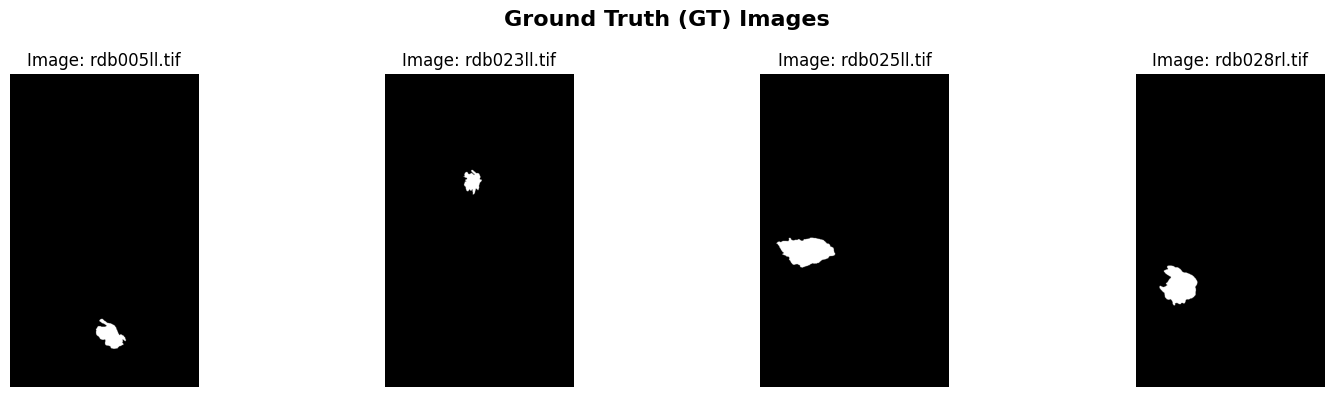

>>> Plotting Algorithms Predictions Grid... <<<


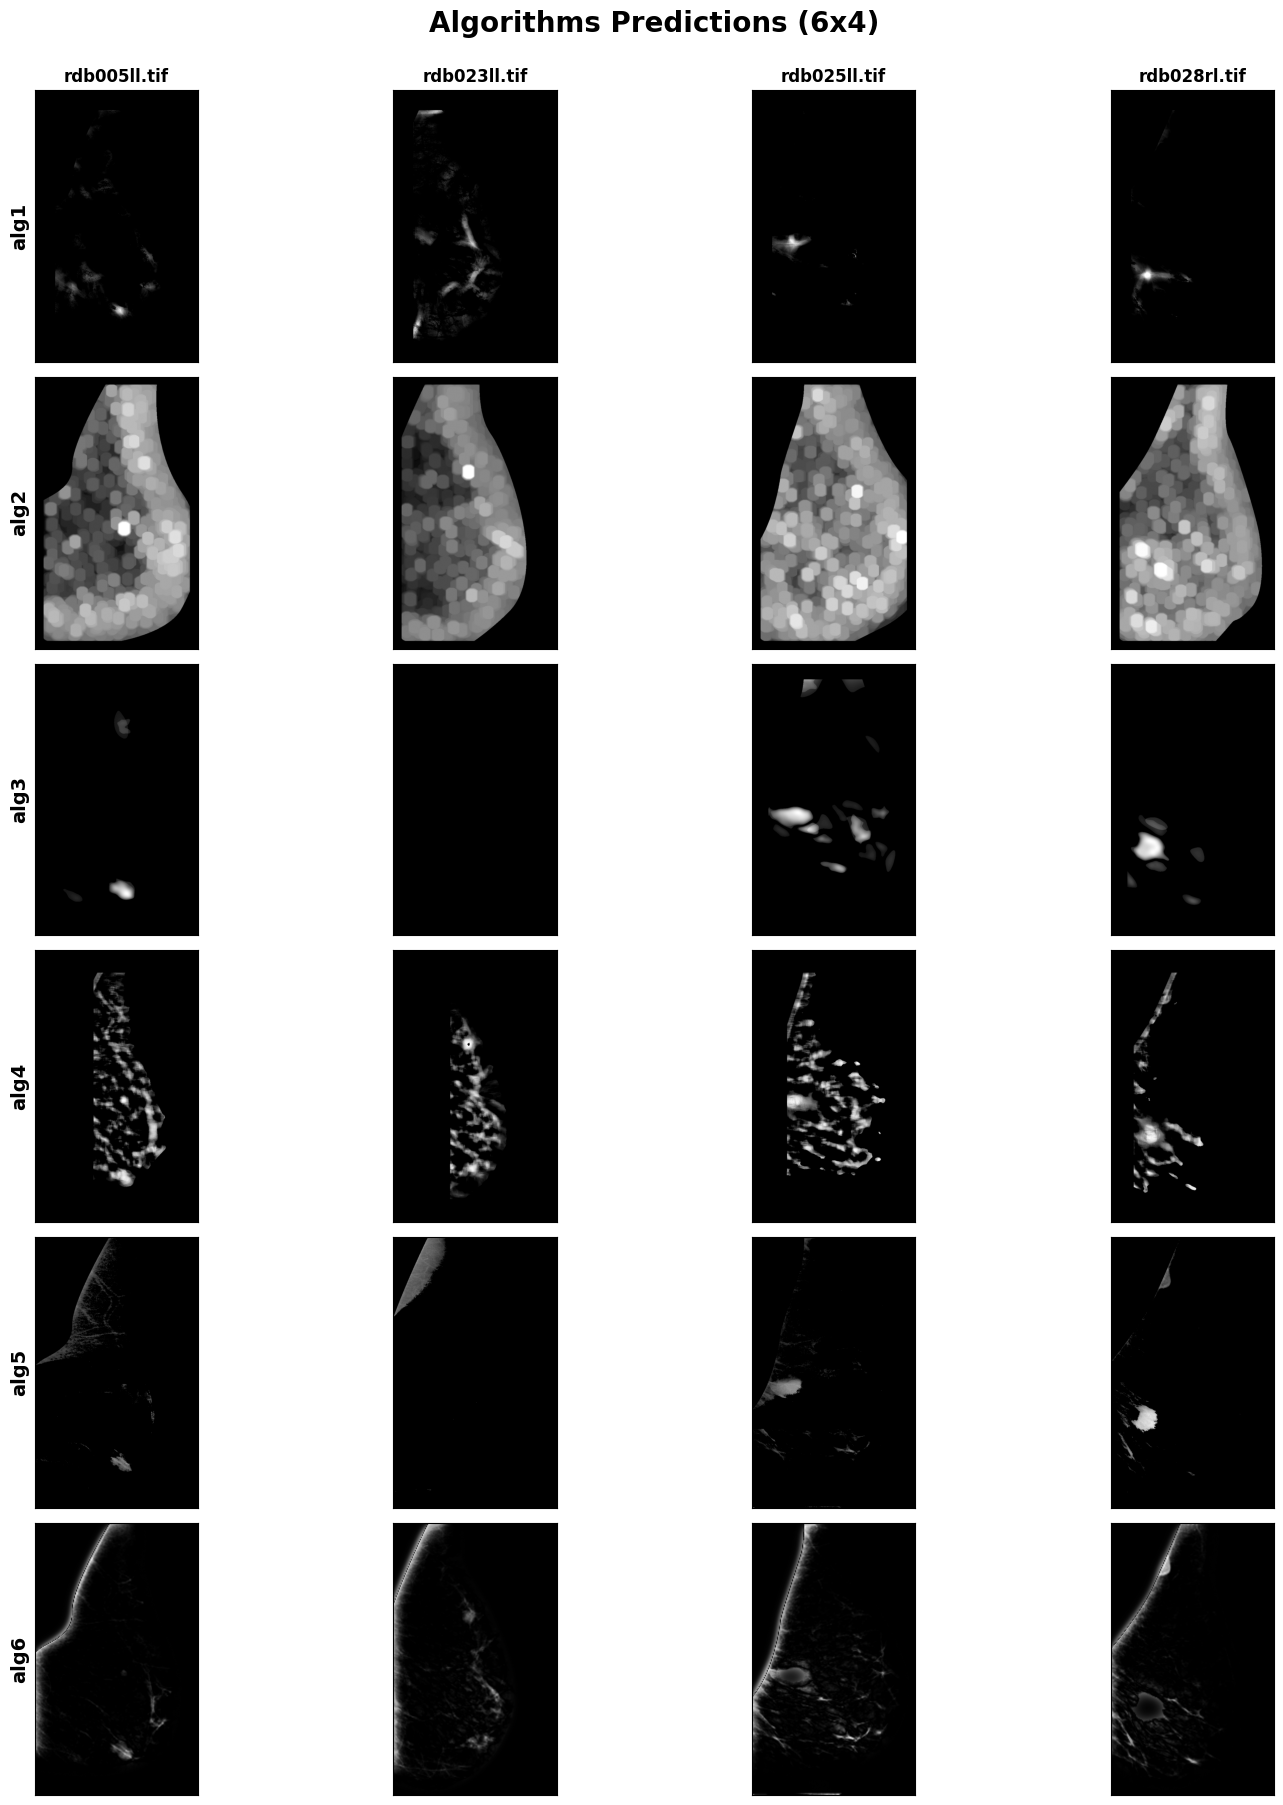

In [7]:
plot_images(GT_DIR, ALGO_DIR)

# ROC Curve and Jaccard Index

In [8]:
def prepare_data_for_roc(gt_images, algo_images):
    gt = np.array(gt_images).flatten()
    algo = np.array(algo_images).flatten()
    
    y_true = (gt > BINARIZATION_THRESHOLD).astype(int) 
    
    y_scores = algo / IMAGE_GRAY_SCALE
    
    return y_true, y_scores

In [9]:
def calculate_roc_manual(y_true, y_scores):
    thresholds = np.unique(y_scores)[::-1]
    thresholds = np.insert(thresholds, 0, np.inf)
    tpr_list = []
    fpr_list = []
    
    P = np.sum(y_true == 1)
    N = np.sum(y_true == 0)
    
    for thresh in thresholds:
        y_pred = (y_scores >= thresh).astype(int)
        
        TP = np.sum((y_pred == 1) & (y_true == 1))
        
        FP = np.sum((y_pred == 1) & (y_true == 0))
        
        TPR = TP / P if P > 0 else 0
        FPR = FP / N if N > 0 else 0
        
        tpr_list.append(TPR)
        fpr_list.append(FPR)
        
    return np.array(fpr_list), np.array(tpr_list), thresholds

In [10]:
def calculate_auc_manual(fpr, tpr):
    auc = 0
    for i in range(1, len(fpr)):
        width = fpr[i] - fpr[i-1]
        avg_height = (tpr[i] + tpr[i-1]) / 2.0
        auc += width * avg_height
        
    return auc

In [11]:
def calculate_jaccard_dice(y_true, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)

    if np.sum(y_true) == 0 and np.sum(y_pred) == 0:
        return 1.0, 1.0
    
    TP = np.sum((y_pred == 1) & (y_true == 1))
    FP = np.sum((y_pred == 1) & (y_true == 0))
    FN = np.sum((y_pred == 0) & (y_true == 1))
    
    jaccard = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0.0
    dice = (2 * jaccard) / (1 + jaccard)
    
    return jaccard, dice

In [12]:
def get_best_jaccard_dice_from_thresholds(y_true, y_scores, thresholds):
    jaccards = [calculate_jaccard_dice(y_true, y_scores, thresh)[0] for thresh in thresholds]

    best_threshold_idx = np.argmax(jaccards)
    jaccard = jaccards[best_threshold_idx]
    best_threshold = thresholds[best_threshold_idx]
    
    dice = (2 * jaccard) / (1 + jaccard)
    
    return best_threshold_idx, best_threshold, jaccard, dice

In [13]:
def plot_algorithms_comparison(title, algo_results):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    
    for algo_name, data in algo_results.items():
        ax1.plot(data['fpr_m'], data['tpr_m'], lw=2, label=f"{algo_name} (AUC = {data['auc_m']:.4f})")
        ax1.plot(data['fpr_m'][data['best_threshold_idx_jaccard']], data['tpr_m'][data['best_threshold_idx_jaccard']], marker='o', color='green', markersize=8)
        ax1.plot(data['fpr_m'][data['best_threshold_idx_roc']], data['tpr_m'][data['best_threshold_idx_roc']], marker='o', color='red', markersize=8)

        ax2.plot(data['fpr_sk'], data['tpr_sk'], lw=2, label=f"{algo_name} (AUC = {data['auc_sk']:.4f})")
        ax2.plot(data['fpr_sk'][data['best_threshold_idx_jaccard']], data['tpr_sk'][data['best_threshold_idx_jaccard']], marker='o', color='green', markersize=8)
        ax2.plot(data['fpr_sk'][data['best_threshold_idx_roc']], data['tpr_sk'][data['best_threshold_idx_roc']], marker='o', color='red', markersize=8)
        

    for ax, ax_title in zip([ax1, ax2], ['Manual ROC', 'Sklearn ROC']):
        ax.plot([0, 1], [0, 1], color='gray', linestyle=':', label='Random Guess')
        ax.plot([], [], marker='o', color='red', linestyle='None', markersize=8, label='Best Thresh (ROC)')
        ax.plot([], [], marker='o', color='green', linestyle='None', markersize=8, label='Best Thresh (Jaccard)')
        ax.set_xlim([0.0, 1.0])
        ax.set_ylim([0.0, 1.05])
        ax.set_xlabel('False Positive Rate (FPR)')
        ax.set_ylabel('True Positive Rate (TPR)')
        ax.set_title(ax_title)
        ax.legend()
        ax.legend(loc="lower right")
        ax.grid(True)
        
    plt.tight_layout()
    plt.show()

In [14]:
def calculate_best_threshold_from_roc(fpr, tpr, thresholds):
    distances = np.sqrt(fpr**2 + (tpr - 1)**2)
    optimal_idx = np.argmin(distances)
    best_thresh = thresholds[optimal_idx]

    return optimal_idx, best_thresh

In [15]:
def compute_roc_metrics(y_true, y_scores):
    fpr_manual, tpr_manual, thresholds_m = calculate_roc_manual(y_true, y_scores)
    auc_manual = calculate_auc_manual(fpr_manual, tpr_manual)
        
    fpr_sklearn, tpr_sklearn, _ = roc_curve(y_true, y_scores, drop_intermediate=False)
    auc_sklearn = auc(fpr_sklearn, tpr_sklearn)
    
    return fpr_manual, tpr_manual, auc_manual, thresholds_m, fpr_sklearn, tpr_sklearn, auc_sklearn

# Hausdorff Distance

In [16]:
def get_boundary_coordinates(mask):
    mask_uint8 = mask.astype(np.uint8)
    
    kernel = np.ones((3, 3), np.uint8)
    eroded_mask = cv2.erode(mask_uint8, kernel, iterations=1)
    
    boundary_mask = mask_uint8 - eroded_mask
    
    boundary_coords = np.argwhere(boundary_mask > 0)
    
    return boundary_coords

In [17]:
def get_directed_hausdorff(coords_A, coords_B):        
    tree_B = cKDTree(coords_B)

    distances, _ = tree_B.query(coords_A)
    
    max_distance = np.max(distances)
    
    return max_distance

In [18]:
def calculate_hausdorff_distance_manual(y_true_img, y_score_img, threshold):
    y_pred_bin = (y_score_img >= threshold).astype(np.uint8)
    y_true_bin = (y_true_img > 0).astype(np.uint8)
    
    coords_true = get_boundary_coordinates(y_true_bin)
    coords_pred = get_boundary_coordinates(y_pred_bin)
    

    if len(coords_true) == 0 and len(coords_pred) == 0:
        return 0.0
        
    if len(coords_true) == 0 or len(coords_pred) == 0:
        return np.inf
        
    d_pred_to_true = get_directed_hausdorff(coords_pred, coords_true)
    d_true_to_pred = get_directed_hausdorff(coords_true, coords_pred)
    
    final_hausdorff = max(d_pred_to_true, d_true_to_pred)
    
    return final_hausdorff

# Printing Metrics

In [19]:
def process_and_print_metrics(algo_name, y_true, y_scores, gt_images_list, algo_images_list):
    fpr_m, tpr_m, auc_m, thresholds_m, fpr_sk, tpr_sk, auc_sk = compute_roc_metrics(y_true, y_scores)
    
    best_th_idx_roc, best_th_roc = calculate_best_threshold_from_roc(fpr_m, tpr_m, thresholds_m)
    jaccard_from_roc, dice_from_roc = calculate_jaccard_dice(y_true, y_scores, best_th_roc)
    
    best_th_idx_jaccard, best_th_jaccard, jaccard_from_jaccard, dice_from_jaccard = get_best_jaccard_dice_from_thresholds(y_true, y_scores, thresholds_m)

    hd_roc_list = []
    hd_jaccard_list = []
    
    for gt_img, algo_img in zip(gt_images_list, algo_images_list):
            
        y_score_img_2d = algo_img / IMAGE_GRAY_SCALE
        
        hd_roc_list.append(calculate_hausdorff_distance_manual(gt_img, y_score_img_2d, best_th_roc))
        hd_jaccard_list.append(calculate_hausdorff_distance_manual(gt_img, y_score_img_2d, best_th_jaccard))

    if len(hd_roc_list) == 1:
        hd_value_roc = f"{hd_roc_list[0]:.4f}"
        hd_value_jaccard = f"{hd_jaccard_list[0]:.4f}"
    elif len(hd_roc_list) > 1:
        hd_value_roc = f"{np.mean(hd_roc_list):.4f} ({np.min(hd_roc_list):.4f} --- {np.max(hd_roc_list):.4f})"
        hd_value_jaccard = f"{np.mean(hd_jaccard_list):.4f} ({np.min(hd_jaccard_list):.4f} --- {np.max(hd_jaccard_list):.4f})"

    print(f"{algo_name:<15} | {auc_m:<10.4f} | {best_th_roc:<35.4f} | {jaccard_from_roc:<15.4f} | {dice_from_roc:<18.4f} | {hd_value_roc:<35} | {best_th_jaccard:<35.4f} | {jaccard_from_jaccard:<15.4f} | {dice_from_jaccard:<18.4f} | {hd_value_jaccard:<35}")
            
    return {
        'fpr_m': fpr_m, 'tpr_m': tpr_m, 'auc_m': auc_m, 
        'fpr_sk': fpr_sk, 'tpr_sk': tpr_sk, 'auc_sk': auc_sk, 
        'best_threshold_idx_roc': best_th_idx_roc, 
        'best_threshold_idx_jaccard': best_th_idx_jaccard
    }

In [20]:
def evaluate_and_compare_all(gt_path, algo_base_path):
    gt_images, gt_filenames = load_images_from_folder(gt_path)
    algorithms = sorted([d for d in os.listdir(algo_base_path) if os.path.isdir(os.path.join(algo_base_path, d))])
    algos_data = {algo: load_images_from_folder(os.path.join(algo_base_path, algo))[0] for algo in algorithms}

    table_header = f"{'Algorithm':<15} | {'AUC':<10} | {'Best Threshold from ROC Curve':<35} | {'Jaccard Index':<15} | {'Dice Coefficient':<18} | {'Hausdorff Distance (px)':<35} | {'Best Threshold from Jaccard Index ':<35} | {'Jaccard Index':<15} | {'Dice Coefficient':<18} | {'Hausdorff Distance (px)':<35}"
    table_divider = "-" * 264


    print(f"{'='*60}\n>>> Model Evaluation per Image <<<\n{'='*60}\n")
    
    for i, (gt_img, filename) in enumerate(zip(gt_images, gt_filenames)):

        print(f"\n--- Image: {filename} ---")
        print(table_header)
        print(table_divider)

        image_results = {} 
        for algo_name in algorithms:
            algo_img = algos_data[algo_name][i] 
            y_true, y_scores = prepare_data_for_roc([gt_img], [algo_img])
            
            image_results[algo_name] = process_and_print_metrics(algo_name, y_true, y_scores, [gt_img], [algo_img])
            
        plot_algorithms_comparison(f'Evaluation per Image: {filename}', image_results)


    print(f"\n{'='*60}\n>>> Model Overall Evaluation <<<\n{'='*60}\n")
    print(table_header)
    print(table_divider)
    
    overall_results = {}
    for algo_name in algorithms:
        algo_imgs = algos_data[algo_name]
        y_true_all, y_scores_all = prepare_data_for_roc(gt_images, algo_imgs)
        
        overall_results[algo_name] = process_and_print_metrics(algo_name, y_true_all, y_scores_all, gt_images, algo_imgs)
            
    plot_algorithms_comparison('Overall Comparison of All Algorithms', overall_results)

>>> Model Evaluation per Image <<<


--- Image: rdb005ll.tif ---
Algorithm       | AUC        | Best Threshold from ROC Curve       | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)             | Best Threshold from Jaccard Index   | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alg1            | 0.7488     | 0.0039                              | 0.0812          | 0.1501             | 767.4282                            | 0.2039                              | 0.1729          | 0.2949             | 460.3792                           
alg2            | 0.8645     | 0.2588                              | 0.0237          | 0.0464             | 828.1510                            | 0.3608

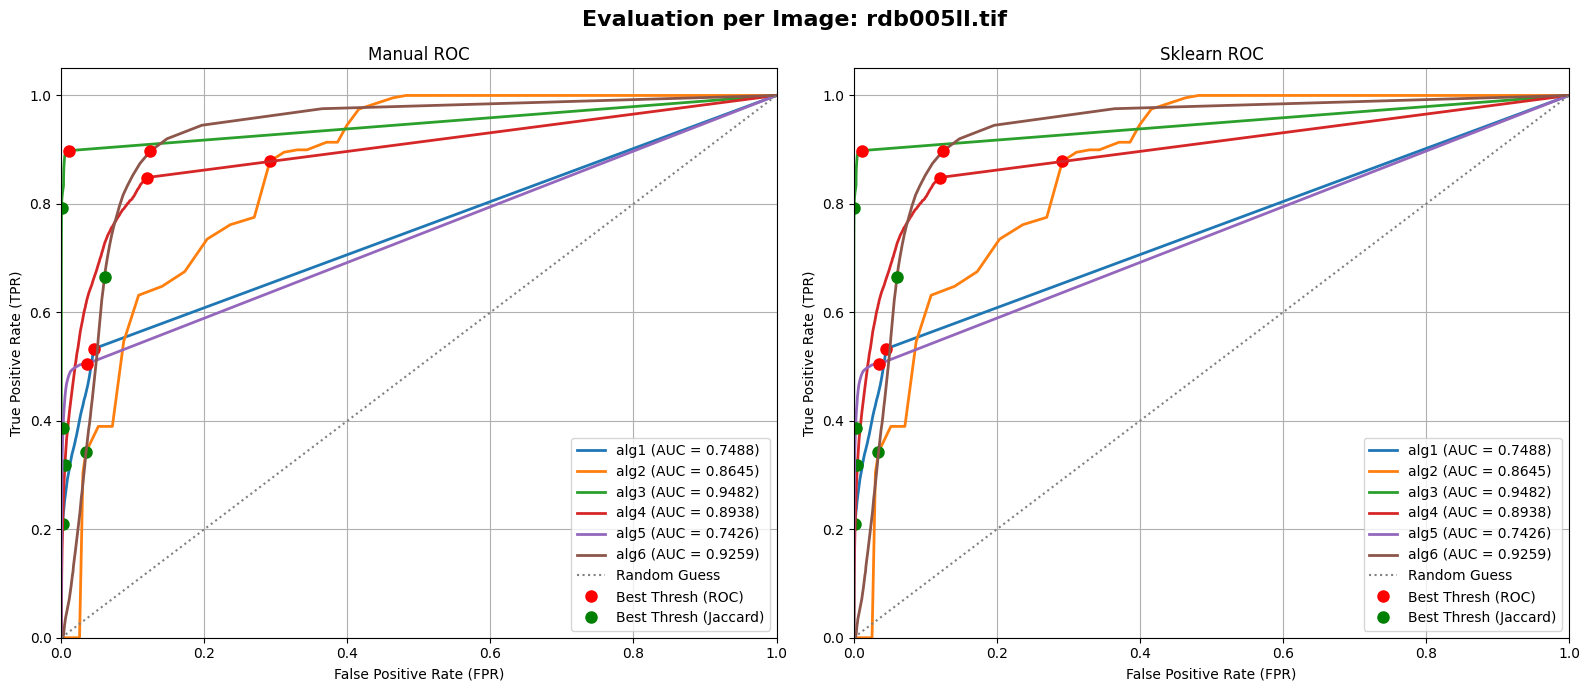


--- Image: rdb023ll.tif ---
Algorithm       | AUC        | Best Threshold from ROC Curve       | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)             | Best Threshold from Jaccard Index   | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alg1            | 0.4586     | 0.0039                              | 0.0011          | 0.0022             | 621.4885                            | 0.0000                              | 0.0045          | 0.0089             | inf                                
alg2            | 0.9669     | 0.4196                              | 0.0378          | 0.0728             | 654.8015                            | 0.6902                              | 0.60

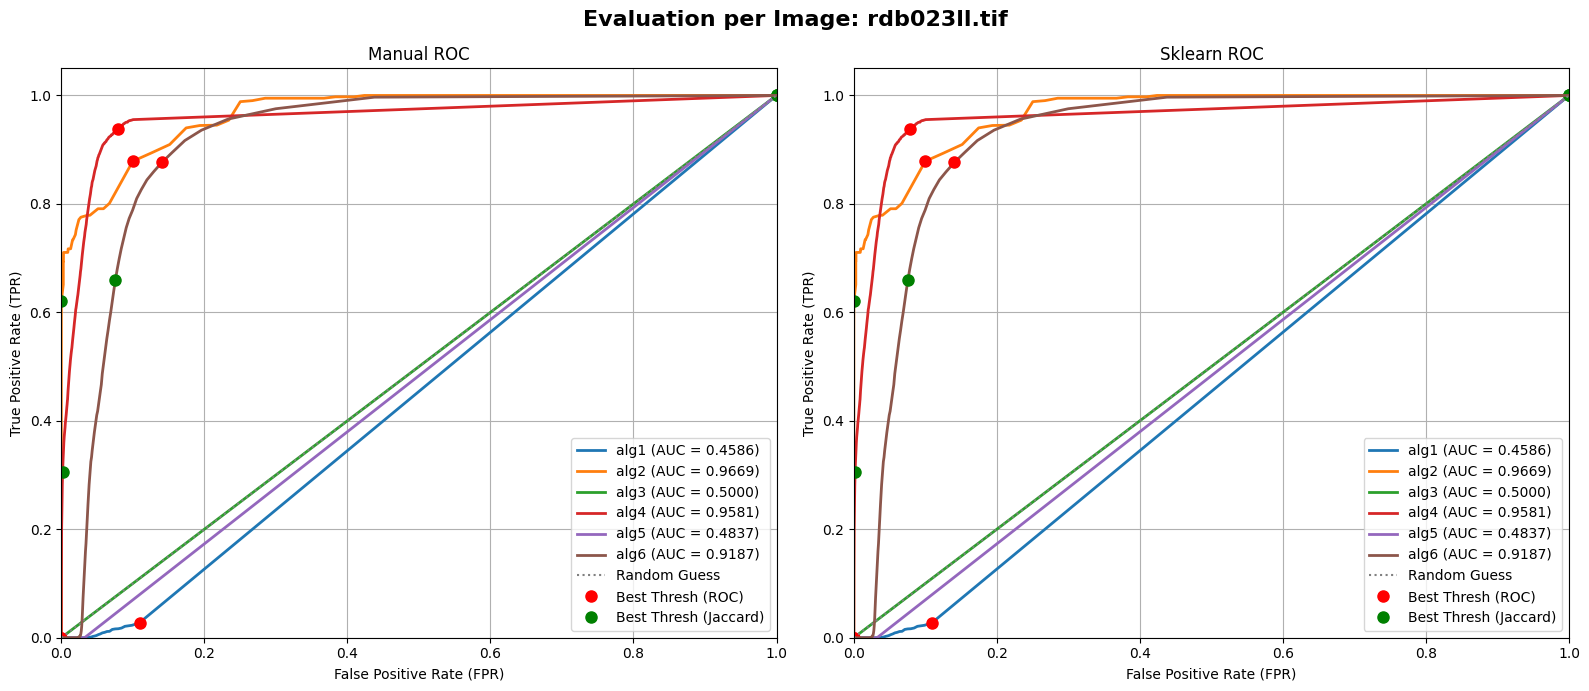


--- Image: rdb025ll.tif ---
Algorithm       | AUC        | Best Threshold from ROC Curve       | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)             | Best Threshold from Jaccard Index   | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alg1            | 0.8393     | 0.0039                              | 0.5999          | 0.7499             | 478.6533                            | 0.0039                              | 0.5999          | 0.7499             | 478.6533                           
alg2            | 0.8373     | 0.3608                              | 0.0530          | 0.1007             | 548.1314                            | 0.4314                              | 0.07

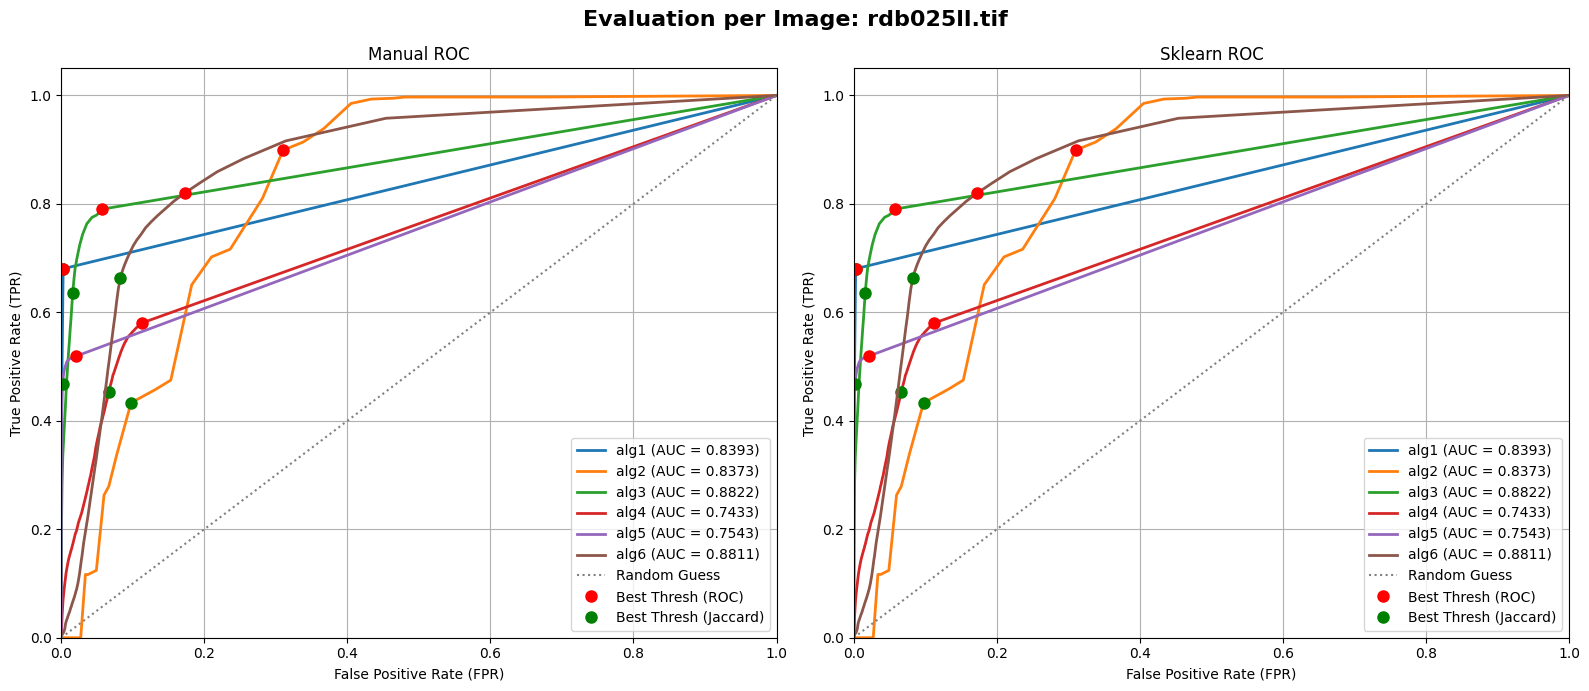


--- Image: rdb028rl.tif ---
Algorithm       | AUC        | Best Threshold from ROC Curve       | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)             | Best Threshold from Jaccard Index   | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alg1            | 0.8632     | 0.0039                              | 0.3740          | 0.5444             | 595.0630                            | 0.0039                              | 0.3740          | 0.5444             | 595.0630                           
alg2            | 0.9075     | 0.3804                              | 0.0740          | 0.1378             | 697.3464                            | 0.5608                              | 0.22

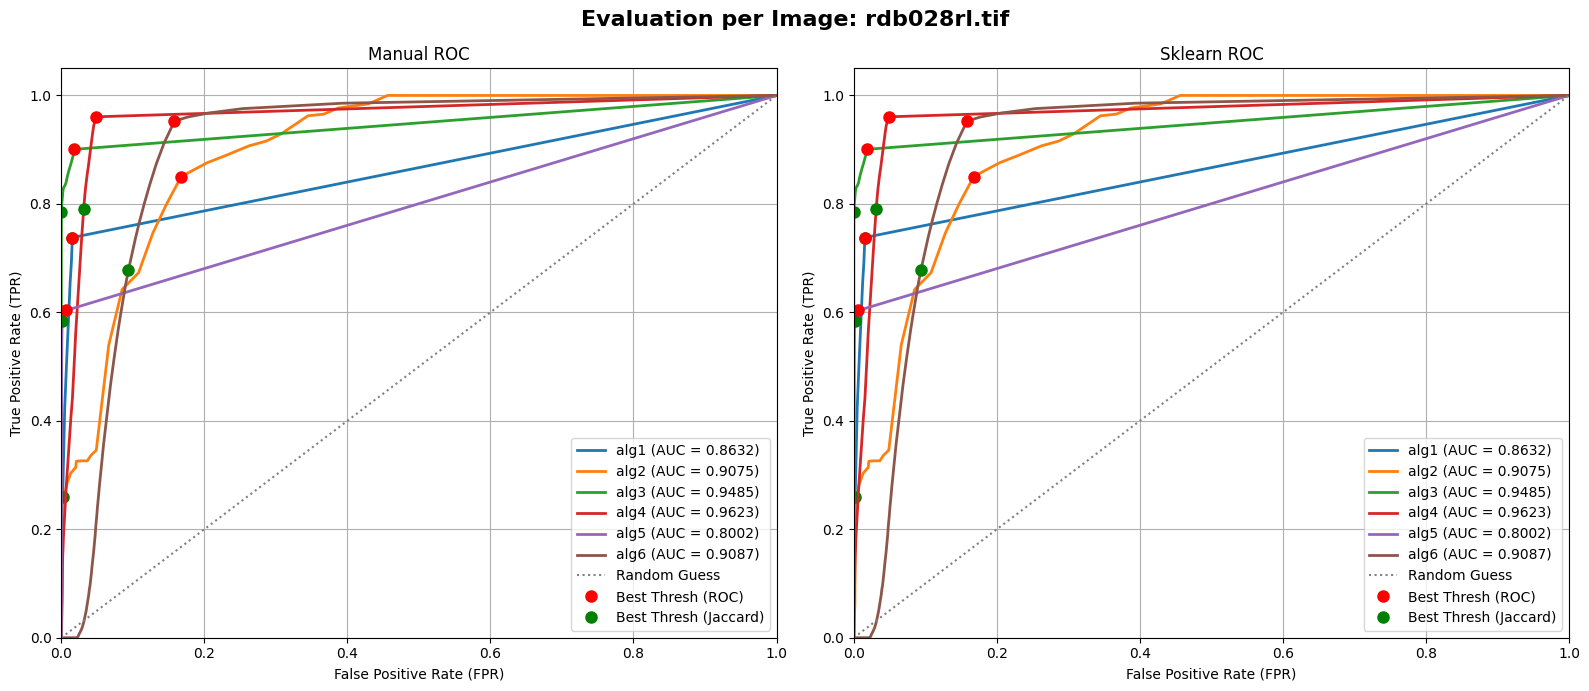


>>> Model Overall Evaluation <<<

Algorithm       | AUC        | Best Threshold from ROC Curve       | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)             | Best Threshold from Jaccard Index   | Jaccard Index   | Dice Coefficient   | Hausdorff Distance (px)            
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
alg1            | 0.7906     | 0.0039                              | 0.1324          | 0.2338             | 615.6583 (478.6533 --- 767.4282)    | 0.1176                              | 0.1903          | 0.3197             | 612.9516 (478.6533 --- 765.3764)   
alg2            | 0.8772     | 0.3608                              | 0.0451          | 0.0863             | 665.5909 (548.1314 --- 745.4187)    | 0.5608                              

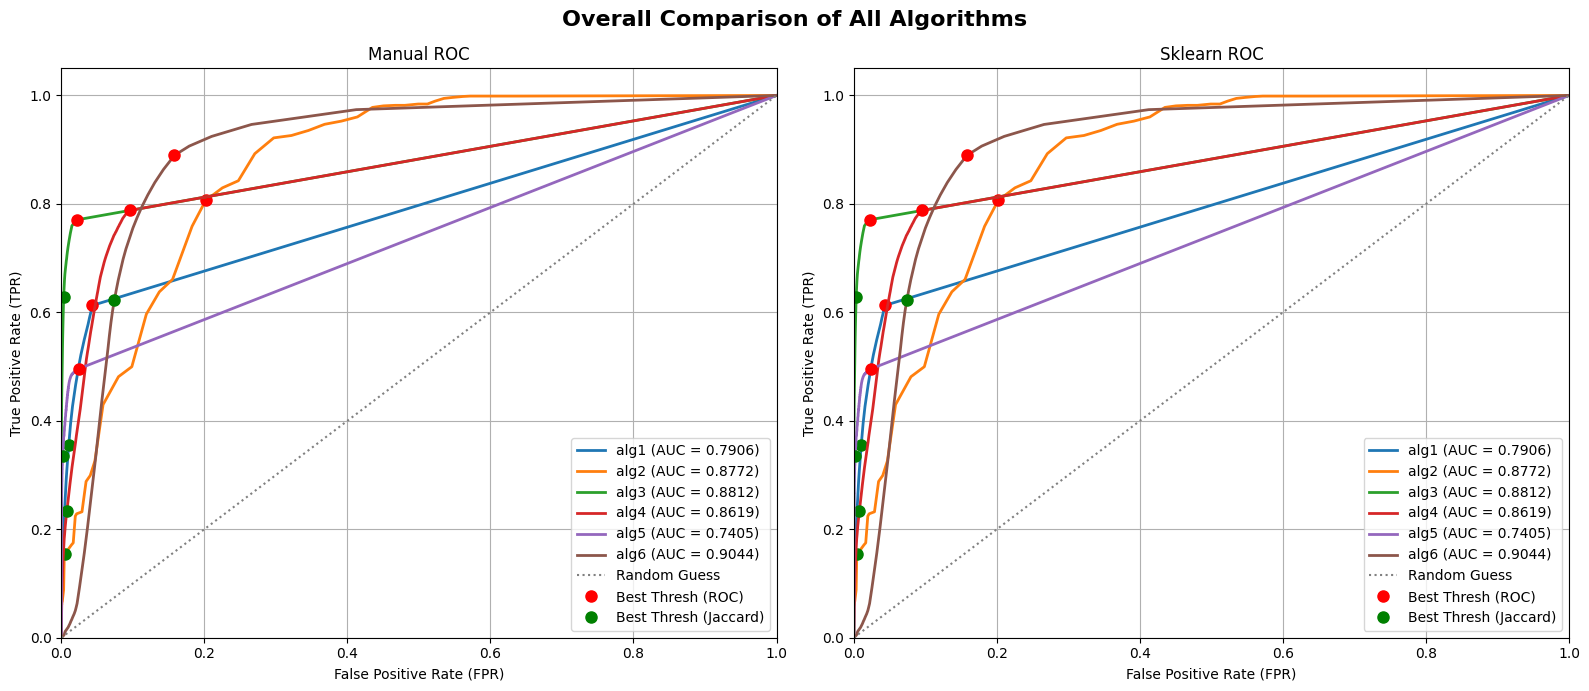

In [21]:
evaluate_and_compare_all(GT_DIR, ALGO_DIR)

# Evaluation of Image-Processing Algorithms for Segmentation 

This study evaluated six different image-processing algorithms to determine the most suitable algorithm and the optimal threshold for image segmentation. Several evaluation methods were examined to identify the most reliable approach.

## Initial Evaluation Metrics

### 1. Area Under the ROC Curve (AUC)
Initially, the Area Under the ROC Curve (AUC) was considered as a metric for comparing the performance of the algorithms. 
* **Initial Finding:** Based on AUC values, Algorithm 6 appeared to be the best-performing algorithm. 
* **The Problem:** When the segmentation results produced by Algorithm 6 were compared with the ground-truth images, they did not produce the highest similarity according to the Jaccard index. 
* **Takeaway:** Relying solely on AUC may not accurately reflect segmentation quality, since AUC evaluates classification performance across thresholds rather than the actual overlap between segmented images and the ground truth.

### 2. ROC Curve Euclidean Distance
Another approach involved selecting the optimal threshold using the Euclidean distance between points on the ROC curve and the ideal point `(0,1)`. 
* **Expectation:** The threshold with the shortest distance to this ideal point was expected to provide the best performance. 
* **The Problem:** In our experiments, this method did not consistently produce the segmentation results that most closely matched the ground truth.

---

## Advanced Evaluation Metrics

### 3. Jaccard Index (Spatial Overlap)
To obtain a more reliable evaluation, the Jaccard index was used to directly measure the similarity between the segmented images generated by each algorithm and the ground-truth images. 
* **Approach:** Using this metric, both the algorithm selection and the threshold optimization were based on the level of overlap between the predicted segmentation and the true segmentation. 
* **Result:** The algorithm that achieved the highest Jaccard index was selected as the best-performing algorithm, and the threshold that maximized the Jaccard index was chosen as the optimal threshold.

### 4. Hausdorff Distance (Boundary Accuracy)
Beyond these area-based metrics, boundary accuracy was evaluated using the Hausdorff Distance, which revealed a crucial edge case:
* **Algorithm 4:** Yielded a numerically better *average* Hausdorff Distance, but deeper inspection showed this was merely because it consistently predicted masks, even though those boundaries were highly inaccurate and far from the ground truth. 
* **Algorithm 3:** Received an "infinite" maximum penalty due to a complete failure on a single, isolated image that resulted in a blank mask. However, when ignoring this singular outlier, Algorithm 3 demonstrated exceptional boundary precision across its successful predictions.

---

## Conclusion and Final Selection

Based on this comprehensive analysis, **Algorithm 3** was definitively selected as the most effective algorithm. 

**Key Justifications:**
* It achieved the highest Jaccard index, demonstrating superior spatial overlap.
* It exhibited highly precise boundary detection across the vast majority of the dataset.

This evaluation highlights that relying solely on AUC is deceptive, and discarding a highly accurate model due to a single Hausdorff distance outlier in favor of a consistently mediocre model is detrimental to the overall system. 

**Final Decision:** Algorithm 3, at the threshold corresponding to its maximum Jaccard index, was identified as the optimal choice for this task, with the understanding that its isolated edge-case failure can be effectively mitigated through targeted image preprocessing.